In [6]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
import joblib
import sys 


# adding the scripts folder

I will be testing from the fourth of may and seeing how it compares to the actual data

In [7]:
sys.path.append("../scripts/")

In [8]:
from vinfast_multiple_predictors import forecaster

In [9]:
test = forecaster(
    input_date='05-05-2026',
    n_periods=7,
    seed_open=3.61,
    seed_close=3.58,
    seed_high=3.61,
    seed_low=3.57,
    
)

test.forecast()

current_date: 2026-05-07 00:00:00, type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>, tz: None
current_date: 2026-05-07 00:00:00, type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>, tz: None
current_date: 2026-05-07 00:00:00, type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>, tz: None
current_date: 2026-05-07 00:00:00, type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>, tz: None
current_date: 2026-05-07 00:00:00, type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>, tz: None
current_date: 2026-05-07 00:00:00, type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>, tz: None
current_date: 2026-05-07 00:00:00, type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>, tz: None
current_date: 2026-05-08 00:00:00, type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>, tz: None
current_date: 2026-05-08 00:00:00, type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>, tz: None
current_date: 2026-05-08 00:00:00, type: <class 'pandas._libs.tslibs.timestamps.Ti

,date,predicted_open,predicted_high,predicted_low,predicted_adjusted_close
0,2026-05-06,3.589262,3.632337,3.538954,3.595433
1,2026-05-07,3.605430,3.623844,3.511495,3.521244
2,2026-05-08,3.513331,3.628652,3.477120,3.508938
3,2026-05-11,3.490184,3.615085,3.453963,3.567726
4,2026-05-12,3.555902,3.581746,3.507879,3.546795
5,2026-05-13,3.527699,3.571604,3.476043,3.529145
6,2026-05-14,3.527696,3.662131,3.485236,3.575404


In [5]:
test.forecast()

,date,predicted_open,predicted_high,predicted_low,predicted_adjusted_close
0,2026-05-06,3.607585,3.621376,3.541556,3.596368
1,2026-05-07,3.617494,3.620935,3.548865,3.581967
2,2026-05-08,3.613157,3.625983,3.562889,3.585087
3,2026-05-11,3.604310,3.627011,3.531698,3.599658
4,2026-05-12,3.620661,3.629941,3.531078,3.596038
5,2026-05-13,3.619512,3.626715,3.544091,3.579253
6,2026-05-14,3.566334,3.613802,3.518287,3.594131


In [6]:
test.calculate_parameters()

,mean,std,min,max,ci_lower_95,ci_upper_95
series,,,,,,
predicted_open,3.6070,0.0189,3.5663,3.6207,3.5895,3.6245
predicted_high,3.6237,0.0054,3.6138,3.6299,3.6187,3.6287
predicted_low,3.5398,0.0144,3.5183,3.5629,3.5265,3.5531
predicted_adjusted_close,3.5904,0.0081,3.5793,3.5997,3.5829,3.5978


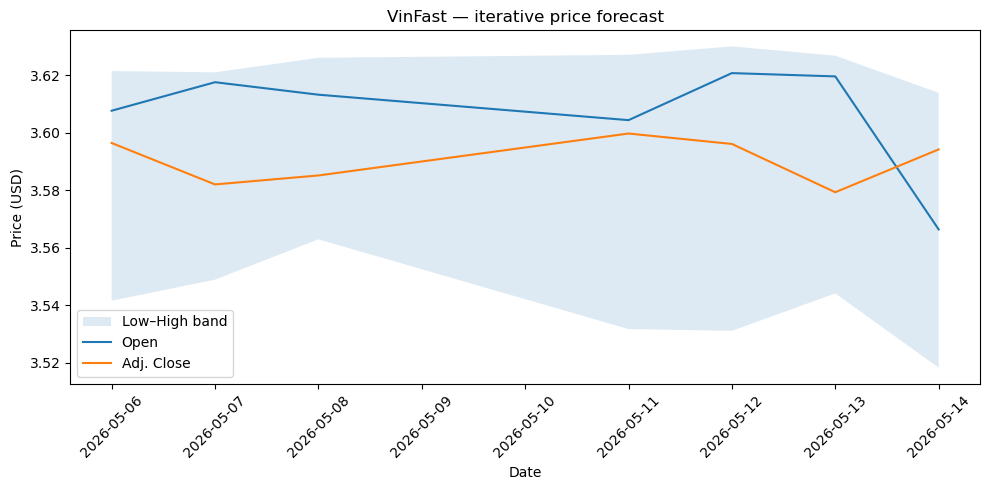

In [7]:
test.plot()

# testing the cleaning script

In [4]:
from clean_time_series import clean_iqr

You have imported the clean_time_series.py module...
This script is based on the idea that you wish to use lagging stock values to predict future stock values
Make sure you have cleaned your data first. This means that:
    1. all columns have been converted to lowercase
    2. all missing/erroenous values have been corrected


In [36]:
# importing test data
df = pd.read_excel("../financial_data/vinfast_stock_data.xlsx")

In [37]:
df

,Date,Open,High,Low,CloseClosing price adjusted for splits.,Adj CloseAdjusted closing price adjusted for splits and dividend and/or capital gain distributions.,Volume
0,2026-04-28 00:00:00,4.16,4.195,4.000,4.060,4.060,834600
1,2026-04-27 00:00:00,4.23,4.340,4.157,4.210,4.210,650700
2,2026-04-24 00:00:00,4.41,4.450,4.335,4.360,4.360,457200
3,2026-04-23 00:00:00,4.57,4.605,4.140,4.410,4.410,1333100
4,2026-04-22 00:00:00,4.88,5.120,4.580,4.690,4.690,1409000
...,...,...,...,...,...,...,...
1160,13 Sept 2021,9.71,9.710,9.710,9.710,9.710,400
1161,10 Sept 2021,9.69,9.690,9.680,9.680,9.680,700
1162,9 Sept 2021,9.61,9.691,9.610,9.682,9.682,400
1163,8 Sept 2021,9.71,9.710,9.710,9.710,9.710,3700


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1165 entries, 0 to 1164
Data columns (total 7 columns):
 #   Column                                                                                               Non-Null Count  Dtype  
---  ------                                                                                               --------------  -----  
 0   Date                                                                                                 1165 non-null   object 
 1   Open                                                                                                 1165 non-null   float64
 2   High                                                                                                 1165 non-null   float64
 3   Low                                                                                                  1165 non-null   float64
 4   CloseClosing price adjusted for splits.                                                              1165 non

In [39]:
df.columns = ['date', 'open', 'high', 'low', 'adjusted_close_splits', 'adjusted_close', 'volume']

In [40]:
df.drop(['adjusted_close_splits'],axis=1,inplace=True)
df.drop(['volume'],axis=1,inplace=True)

In [41]:
df.reset_index(inplace=True)
df

,index,date,open,high,low,adjusted_close
0,0,2026-04-28 00:00:00,4.16,4.195,4.000,4.060
1,1,2026-04-27 00:00:00,4.23,4.340,4.157,4.210
2,2,2026-04-24 00:00:00,4.41,4.450,4.335,4.360
3,3,2026-04-23 00:00:00,4.57,4.605,4.140,4.410
4,4,2026-04-22 00:00:00,4.88,5.120,4.580,4.690
...,...,...,...,...,...,...
1160,1160,13 Sept 2021,9.71,9.710,9.710,9.710
1161,1161,10 Sept 2021,9.69,9.690,9.680,9.680
1162,1162,9 Sept 2021,9.61,9.691,9.610,9.682
1163,1163,8 Sept 2021,9.71,9.710,9.710,9.710


In [42]:
df['date'] = pd.to_datetime(df['date'])


In [43]:
df

,index,date,open,high,low,adjusted_close
0,0,2026-04-28,4.16,4.195,4.000,4.060
1,1,2026-04-27,4.23,4.340,4.157,4.210
2,2,2026-04-24,4.41,4.450,4.335,4.360
3,3,2026-04-23,4.57,4.605,4.140,4.410
4,4,2026-04-22,4.88,5.120,4.580,4.690
...,...,...,...,...,...,...
1160,1160,2021-09-13,9.71,9.710,9.710,9.710
1161,1161,2021-09-10,9.69,9.690,9.680,9.680
1162,1162,2021-09-09,9.61,9.691,9.610,9.682
1163,1163,2021-09-08,9.71,9.710,9.710,9.710


In [44]:
clean_iqr_test = clean_iqr(df=df)

-------------------------------
this is the clean_iqr module. This uses the interquartile range to identify anomalies...


In [45]:
clean_iqr_test.fit()

Calculating the upper, lower, median and iqr...
Analysing column: index
Analysing column: open
Analysing column: high
Analysing column: low
Analysing column: adjusted_close


In [46]:
clean_iqr_test.get_column_stats()

,column,iqr,median,upper,lower
0,index,582.00,582.00,1746.000,-582.000
1,open,6.11,6.07,18.915,-5.525
2,high,6.02,6.21,18.790,-5.290
3,low,6.19,5.78,19.035,-5.725
4,adjusted_close,6.13,5.99,18.945,-5.575


In [47]:
new_df = df.copy() 
new_df_transformed = clean_iqr_test.transform(new_df)
new_df_transformed

Transforming... Dataframe
median: [582.]
upper: [1746.]
lower: [-582.]
Transforming... Dataframe
median: [6.07]
upper: [18.915]
lower: [-5.525]
Transforming... Dataframe
median: [6.21]
upper: [18.79]
lower: [-5.29]
Transforming... Dataframe
median: [5.78]
upper: [19.035]
lower: [-5.725]
Transforming... Dataframe
median: [5.99]
upper: [18.945]
lower: [-5.575]


,index,open,high,low,adjusted_close
date,,,,,
2026-04-28,0,4.16,4.195,4.000,4.060
2026-04-27,1,4.23,4.340,4.157,4.210
2026-04-24,2,4.41,4.450,4.335,4.360
2026-04-23,3,4.57,4.605,4.140,4.410
2026-04-22,4,4.88,5.120,4.580,4.690
...,...,...,...,...,...
2021-09-13,1160,9.71,9.710,9.710,9.710
2021-09-10,1161,9.69,9.690,9.680,9.680
2021-09-09,1162,9.61,9.691,9.610,9.682


In [48]:
new_df

,index,open,high,low,adjusted_close
date,,,,,
2026-04-28,0,4.16,4.195,4.000,4.060
2026-04-27,1,4.23,4.340,4.157,4.210
2026-04-24,2,4.41,4.450,4.335,4.360
2026-04-23,3,4.57,4.605,4.140,4.410
2026-04-22,4,4.88,5.120,4.580,4.690
...,...,...,...,...,...
2021-09-13,1160,9.71,9.710,9.710,9.710
2021-09-10,1161,9.69,9.690,9.680,9.680
2021-09-09,1162,9.61,9.691,9.610,9.682


In [49]:
np.unique(new_df == new_df_transformed)

array([ True])

In [50]:
# I could include a feature where you can extract the features
a = 2
a is not None

True

In [2]:
!ls -lah ../financial_data/

total 672
drwxr-xr-x   7 thomasnguyen  staff   224B 22 May 12:15 .
drwxr-xr-x  28 thomasnguyen  staff   896B 18 Jun 09:27 ..
-rw-r--r--@  1 thomasnguyen  staff   6.0K 22 May 12:10 .DS_Store
-rw-r--r--@  1 thomasnguyen  staff    13K 22 Apr 17:48 17_04_2026_us.csv
drwxr-xr-x   4 thomasnguyen  staff   128B 30 Apr 10:31 news
-rw-r--r--@  1 thomasnguyen  staff    43K 22 May 12:05 vinfast_stock_data_7_9_2021_to_21_5_2026.xlsx
-rw-r--r--@  1 thomasnguyen  staff   265K 29 Apr 13:06 vinfast_stock_data_7_9_2021_to_28_4_2026.xlsx


In [3]:
df = pd.read_csv("../data/vinfast_data_cleaned.csv")

In [4]:
df.head()

,Unnamed: 0,date,open,high,low,close,adjusted_close,volume
0,0,2024-01-02,8.040,8.05,7.000,7.05,7.05,6666200
1,1,2024-01-03,7.135,7.21,6.835,7.08,7.08,4709600
2,2,2024-01-04,7.070,7.13,6.900,7.07,7.07,3466600
3,3,2024-01-05,7.000,7.06,6.900,7.02,7.02,1939900
4,4,2024-01-08,7.050,7.19,6.750,6.79,6.79,3767900


In [5]:
df.tail()

,Unnamed: 0,date,open,high,low,close,adjusted_close,volume
594,594,2026-05-14,4.01,4.045,3.782,3.89,3.89,763500
595,595,2026-05-15,3.82,3.940,3.761,3.83,3.83,568100
596,596,2026-05-18,3.83,3.865,3.670,3.67,3.67,584000
597,597,2026-05-19,3.65,3.675,3.510,3.53,3.53,583900
598,598,2026-05-20,3.56,3.669,3.540,3.60,3.60,366400


In [10]:
df = pd.read_csv("../data/vinfast_data_cleaned.csv")

In [11]:
df

,Unnamed: 0,date,open,high,low,close,adjusted_close,volume
0,0,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
1,1,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
2,2,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
3,3,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
4,4,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...,...
594,594,2026-05-14,4.010,4.045,3.782,3.89,3.89,763500
595,595,2026-05-15,3.820,3.940,3.761,3.83,3.83,568100
596,596,2026-05-18,3.830,3.865,3.670,3.67,3.67,584000
597,597,2026-05-19,3.650,3.675,3.510,3.53,3.53,583900


In [26]:
from dotenv import load_dotenv 
import os
import requests
import pandas as pd 
from pandas import json_normalize
load_dotenv() 
eod_key = os.getenv("fin_historical_data")
try:

    eod_request = requests.get(f"https://eodhd.com/api/eod/VFS?api_token={eod_key}&fmt=json&from=2026-01-01&to=2026-02-02")

    print (f"historical vinfast status code: {eod_request.status_code}")

    eod_data = json_normalize(eod_request.json())
    print (f"eod data preview: {eod_data.head()}")
    eod_data['date'] = pd.to_datetime(eod_data['date']) 

except Exception as eod_e: 
    print (f"There was an error: {eod_e}")
finally: 
    print ("---------------") 

historical vinfast status code: 200
eod data preview:          date  open   high    low  close  adjusted_close  volume
0  2026-01-02  3.34  3.386  3.330   3.38            3.38  248300
1  2026-01-05  3.39  3.460  3.345   3.45            3.45  364200
2  2026-01-06  3.43  3.600  3.393   3.55            3.55  654400
3  2026-01-07  3.54  3.540  3.400   3.42            3.42  244900
4  2026-01-08  3.42  3.450  3.400   3.45            3.45  161700
---------------


In [27]:
eod_data

,date,open,high,low,close,adjusted_close,volume
0,2026-01-02,3.340,3.386,3.330,3.38,3.38,248300
1,2026-01-05,3.390,3.460,3.345,3.45,3.45,364200
2,2026-01-06,3.430,3.600,3.393,3.55,3.55,654400
3,2026-01-07,3.540,3.540,3.400,3.42,3.42,244900
4,2026-01-08,3.420,3.450,3.400,3.45,3.45,161700
5,2026-01-09,3.450,3.450,3.400,3.43,3.43,208400
6,2026-01-12,3.395,3.430,3.360,3.43,3.43,251600
7,2026-01-13,3.430,3.500,3.385,3.49,3.49,346500
8,2026-01-14,3.420,3.450,3.400,3.43,3.43,204900
9,2026-01-15,3.430,3.495,3.425,3.48,3.48,165100


In [17]:
df = df.drop(['Unnamed: 0'],axis=1)
df

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...
594,2026-05-14,4.010,4.045,3.782,3.89,3.89,763500
595,2026-05-15,3.820,3.940,3.761,3.83,3.83,568100
596,2026-05-18,3.830,3.865,3.670,3.67,3.67,584000
597,2026-05-19,3.650,3.675,3.510,3.53,3.53,583900


In [18]:
df = pd.concat([df, eod_data],axis=0)

In [19]:
df

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...
246,2026-06-11 00:00:00,282.840,286.250,281.040,284.77,284.77,4565400
247,2026-06-12 00:00:00,286.000,287.660,284.030,284.81,284.81,4028800
248,2026-06-15 00:00:00,284.230,288.240,283.600,286.12,286.12,4388500
249,2026-06-16 00:00:00,288.000,289.290,285.090,287.93,287.93,3874300


In [20]:
df['date'] = pd.to_datetime(df['date'])

In [21]:
df

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...
246,2026-06-11,282.840,286.250,281.040,284.77,284.77,4565400
247,2026-06-12,286.000,287.660,284.030,284.81,284.81,4028800
248,2026-06-15,284.230,288.240,283.600,286.12,286.12,4388500
249,2026-06-16,288.000,289.290,285.090,287.93,287.93,3874300


In [23]:
df.drop_duplicates(subset=['date'], inplace=True) 
df

,date,open,high,low,close,adjusted_close,volume
0,2024-01-02,8.040,8.050,7.000,7.05,7.05,6666200
1,2024-01-03,7.135,7.210,6.835,7.08,7.08,4709600
2,2024-01-04,7.070,7.130,6.900,7.07,7.07,3466600
3,2024-01-05,7.000,7.060,6.900,7.02,7.02,1939900
4,2024-01-08,7.050,7.190,6.750,6.79,6.79,3767900
...,...,...,...,...,...,...,...
246,2026-06-11,282.840,286.250,281.040,284.77,284.77,4565400
247,2026-06-12,286.000,287.660,284.030,284.81,284.81,4028800
248,2026-06-15,284.230,288.240,283.600,286.12,286.12,4388500
249,2026-06-16,288.000,289.290,285.090,287.93,287.93,3874300


In [29]:
a = pd.to_datetime('2026-02-02')
str(a).split(" ")[0]

'2026-02-02'

In [31]:
str(max(df['date']))

'2026-06-17 00:00:00'